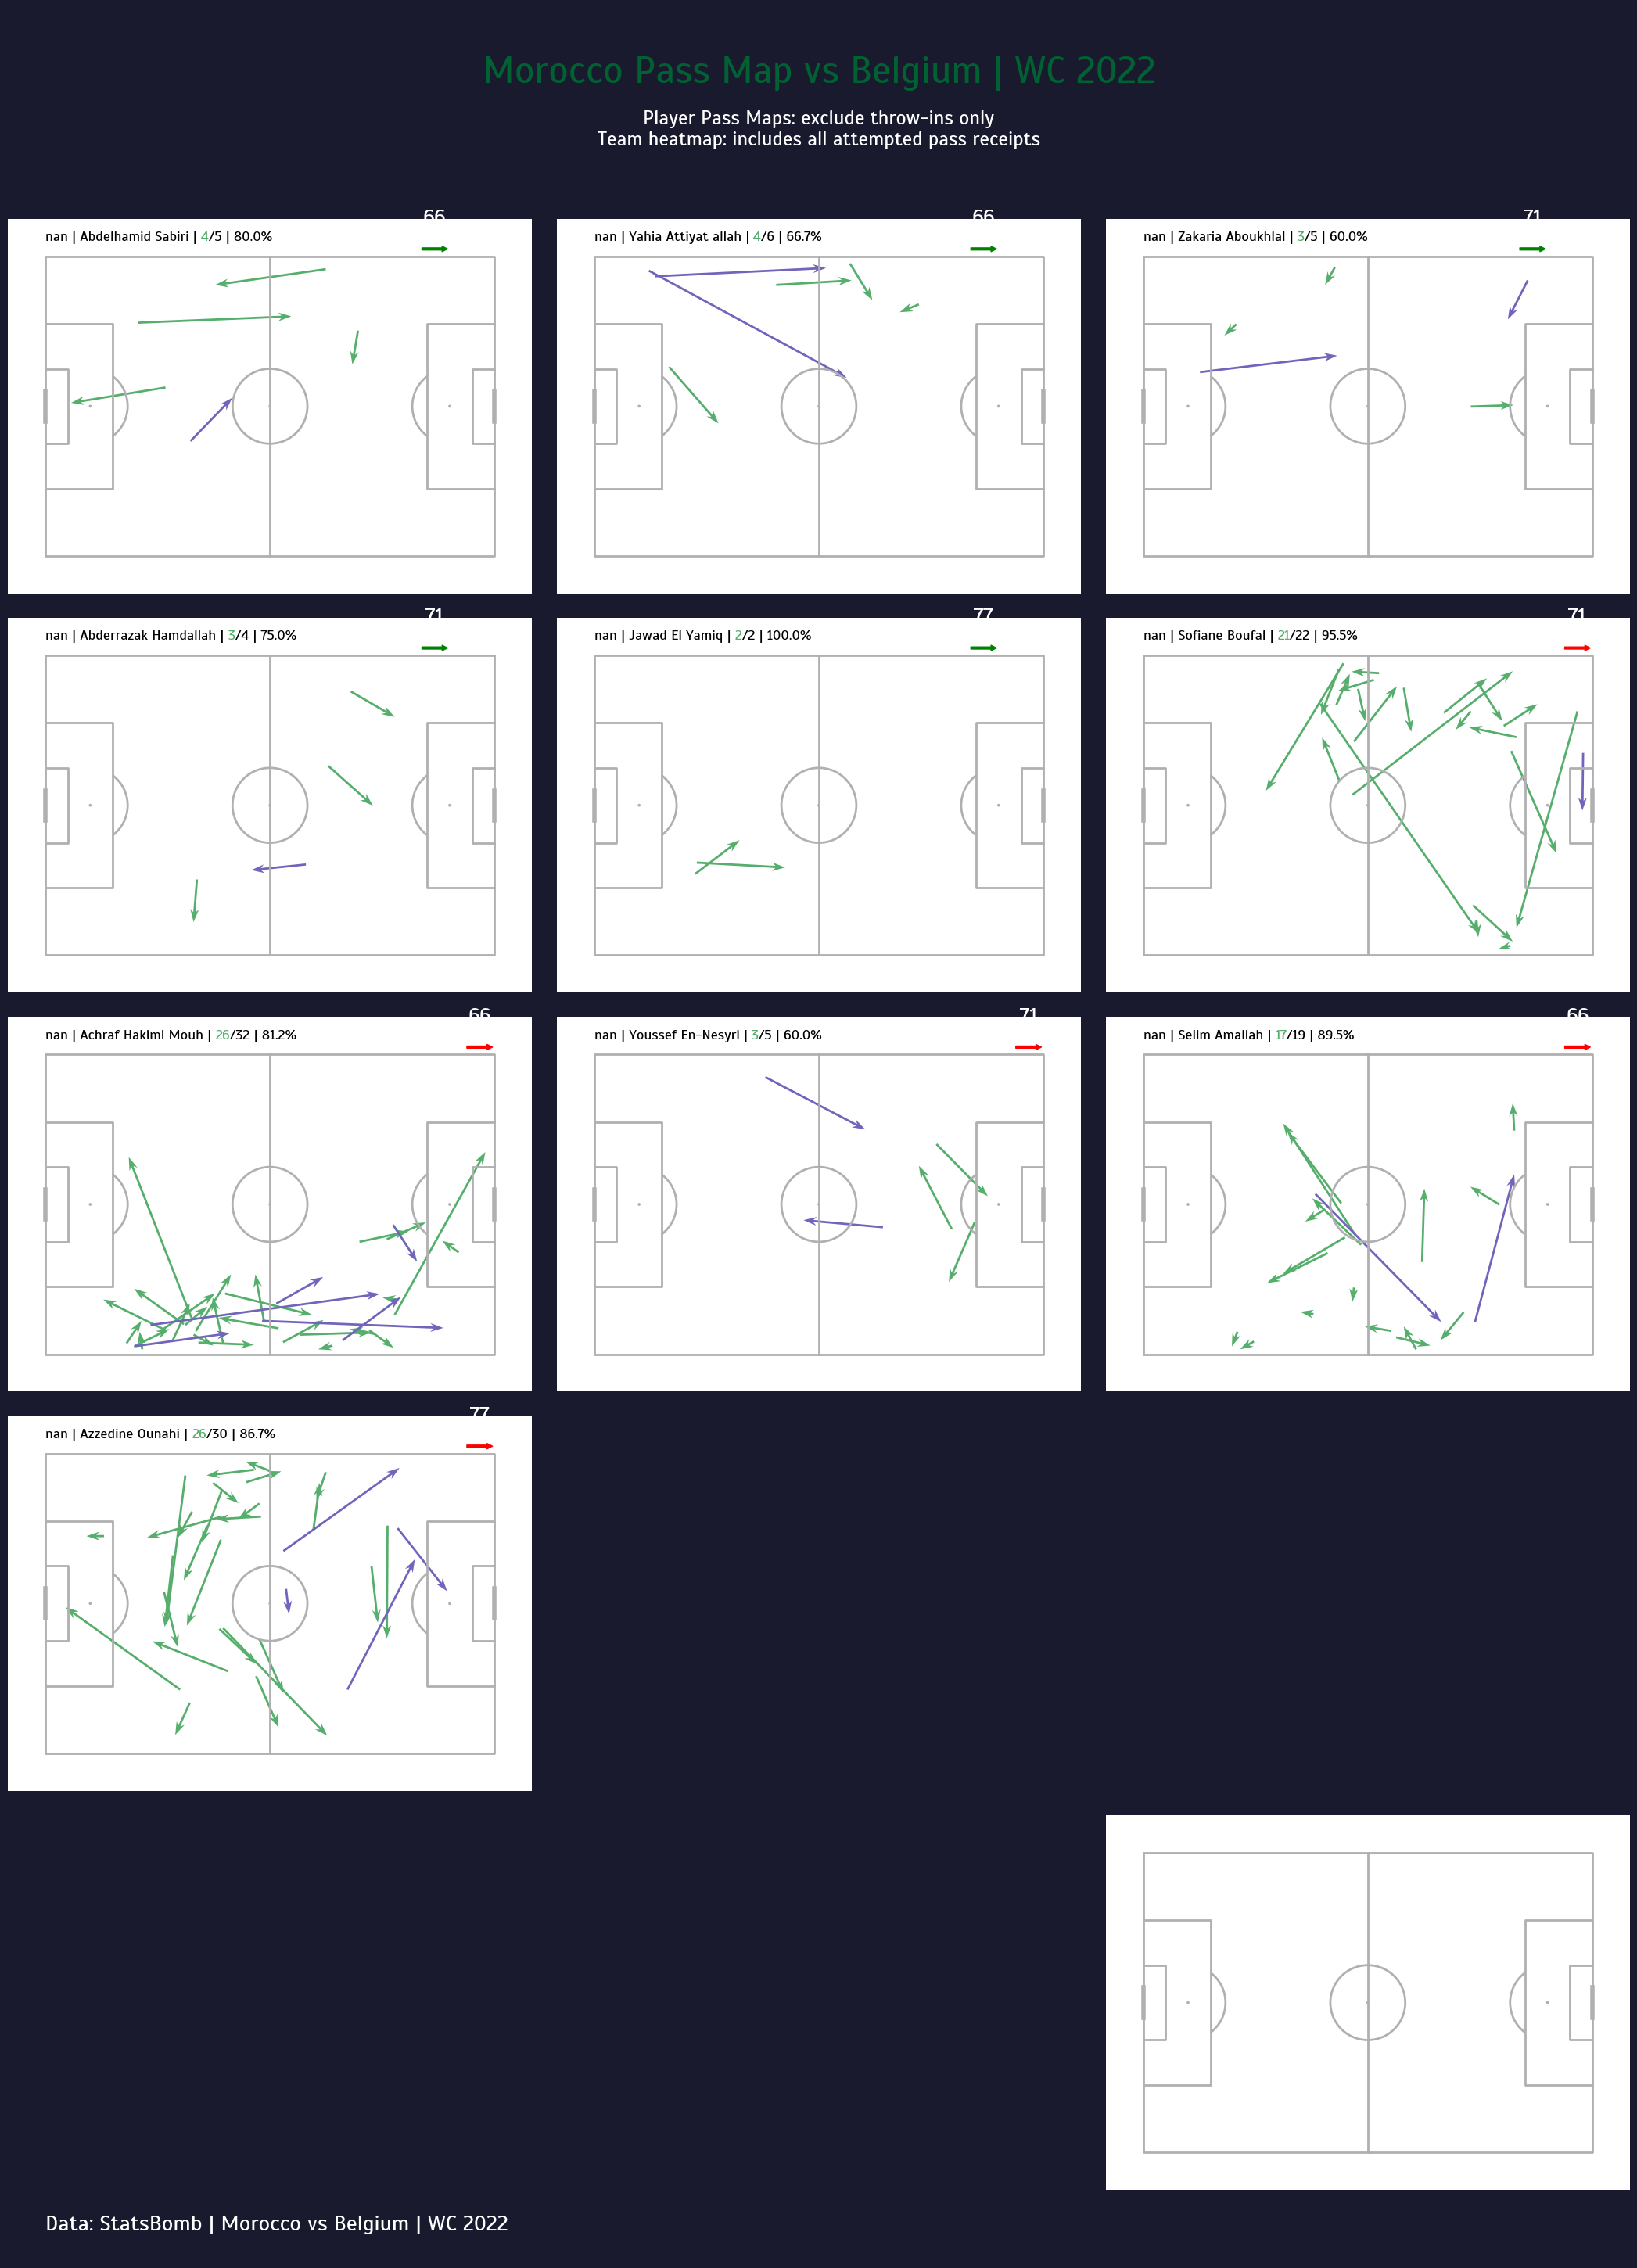

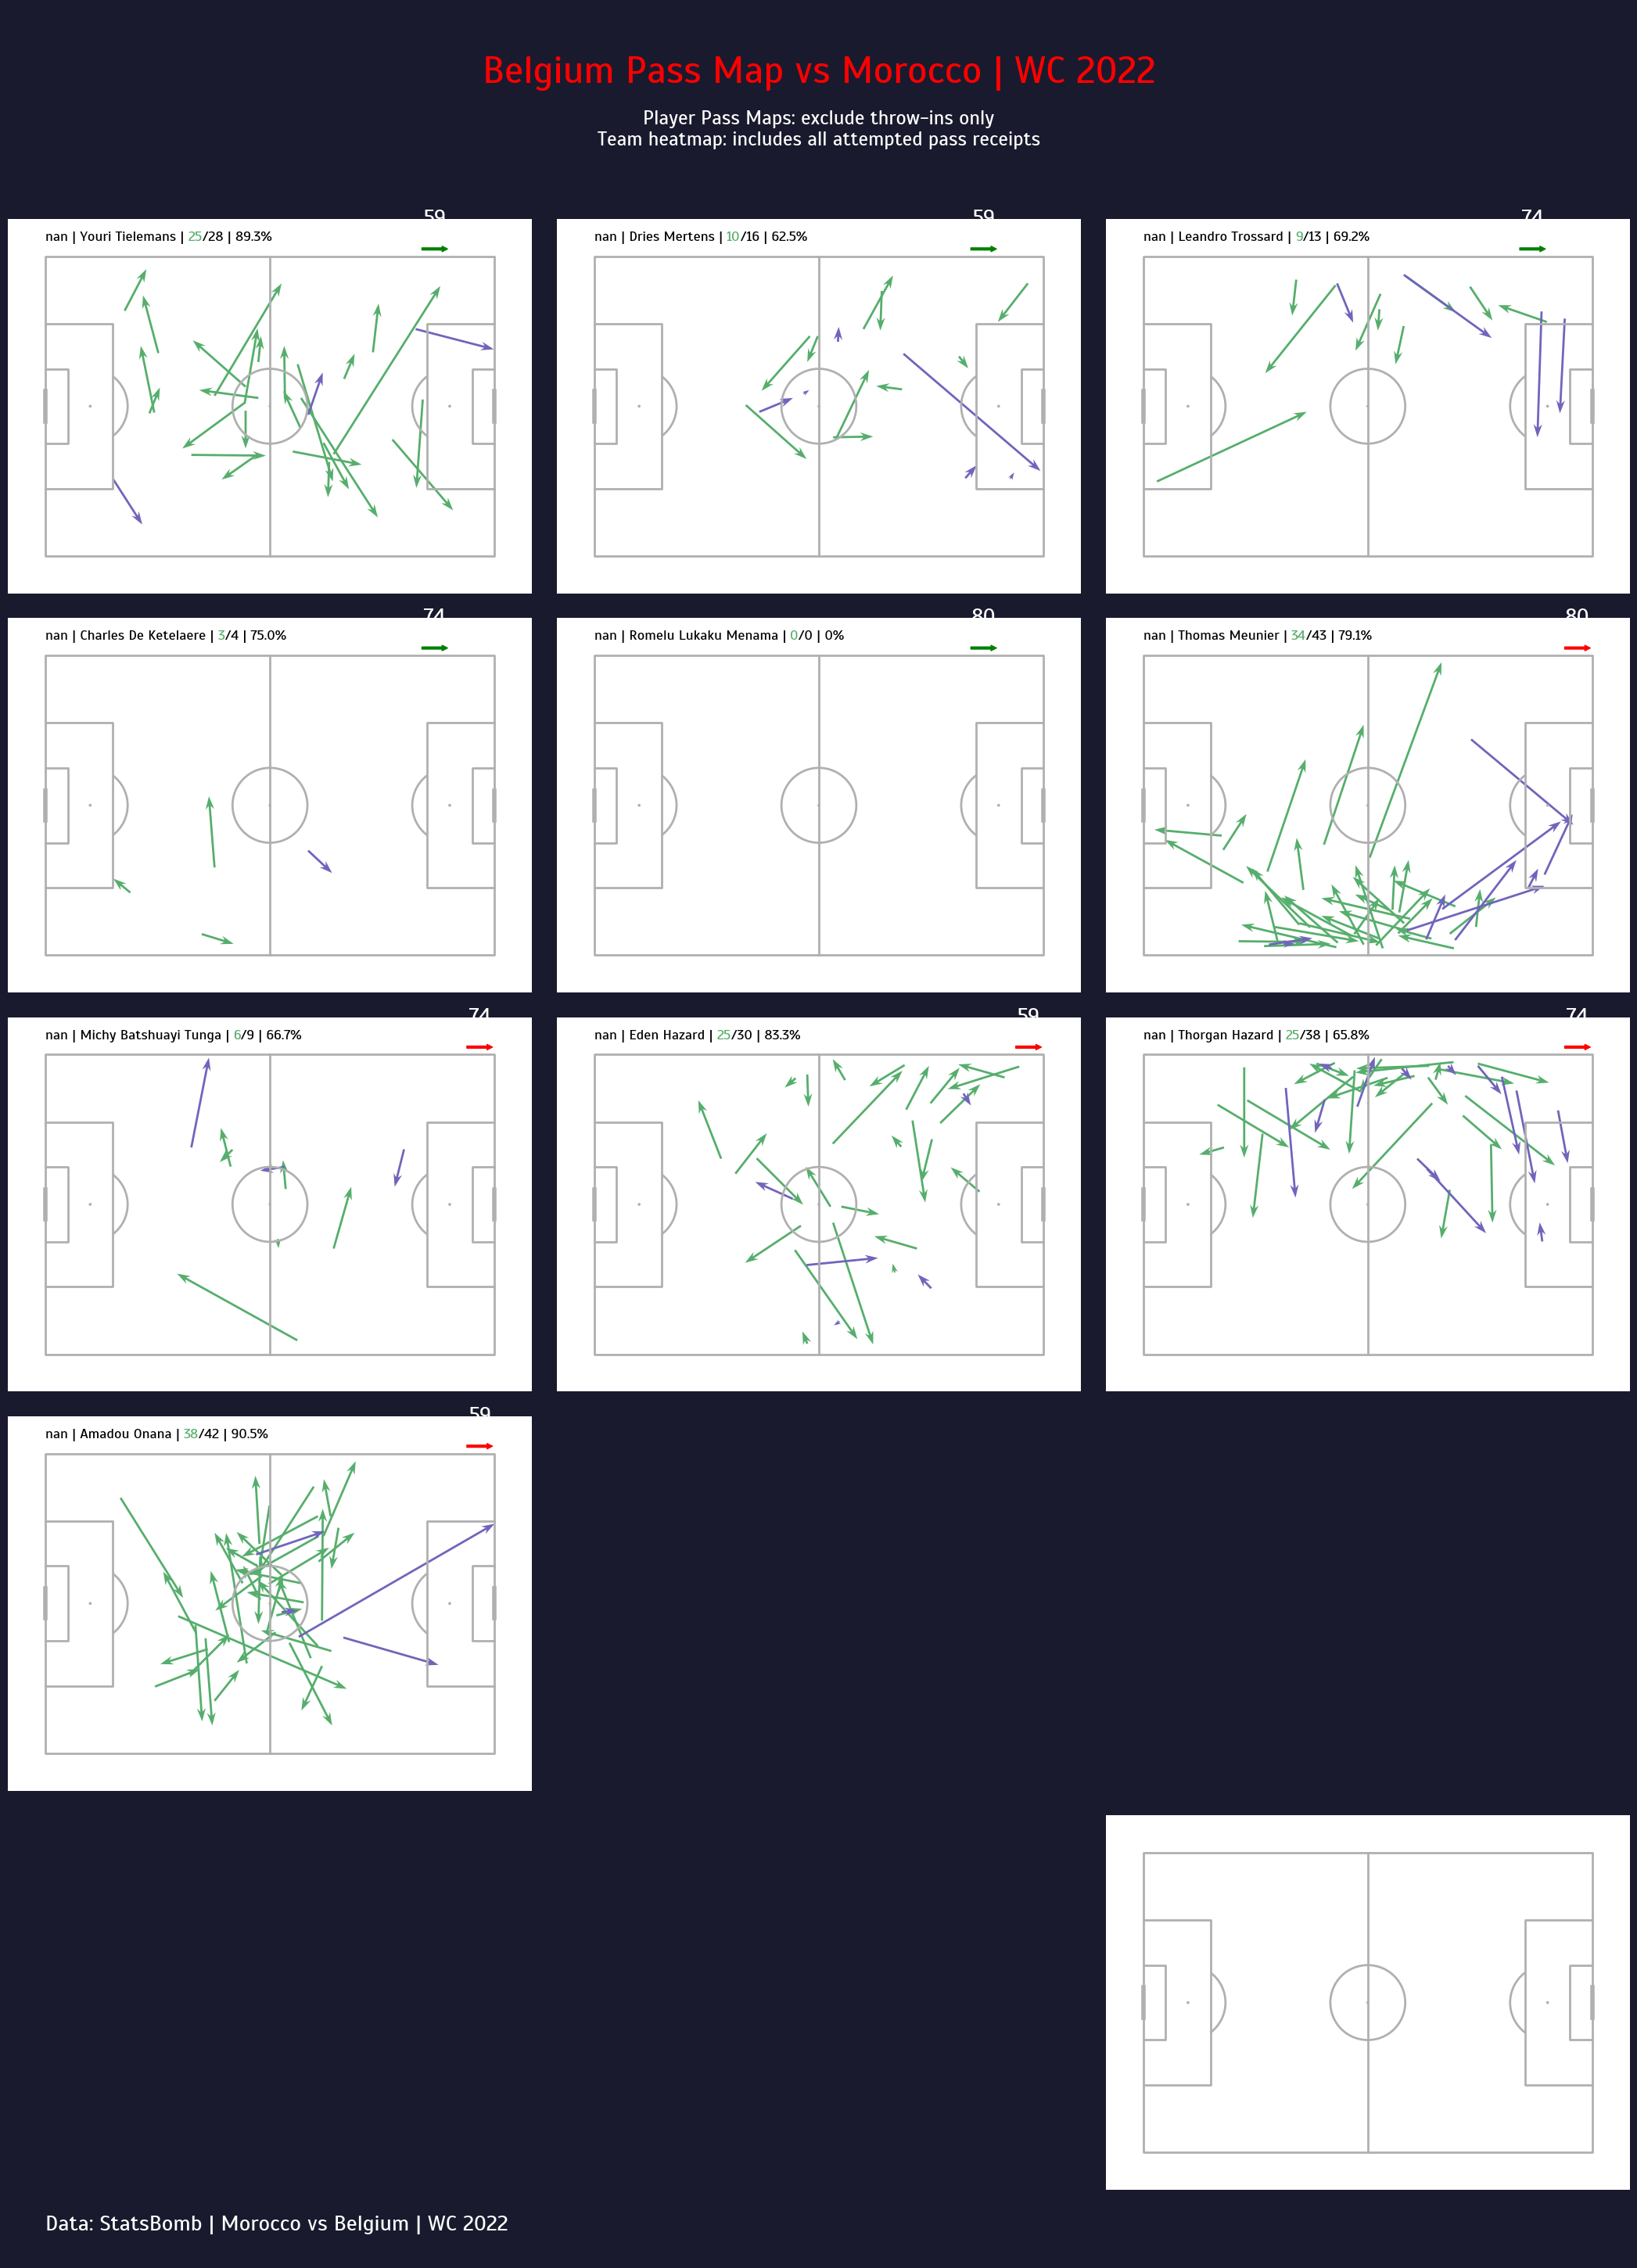

In [41]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mplsoccer import Pitch, FontManager, add_image
from highlight_text import ax_text
from statsbombpy import sb

# ── Fonts ─────────────────────────────────────────────────────────────────────
fm_scada = FontManager('https://raw.githubusercontent.com/googlefonts/scada/main/fonts/ttf/Scada-Regular.ttf')

# ── Load events ───────────────────────────────────────────────────────────────
events = sb.events(match_id=3857283)

# ── Rename columns ────────────────────────────────────────────────────────────
events.rename(columns={
    'type':                     'type_name',
    'team':                     'team_name',
    'player':                   'player_name',
    'position':                 'position_name',
    'pass_outcome':             'outcome_name',
    'pass_type':                'sub_type_name',
    'substitution_replacement': 'substitution_replacement_name',
}, inplace=True)

# ── Extract x, y coordinates safely ──────────────────────────────────────────
def extract_coords(loc):
    if isinstance(loc, list) and len(loc) >= 2:
        return loc[0], loc[1]
    return np.nan, np.nan

events[['x', 'y']] = pd.DataFrame(
    events['location'].apply(extract_coords).tolist(),
    index=events.index
)

if 'pass_end_location' in events.columns:
    events[['end_x', 'end_y']] = pd.DataFrame(
        events['pass_end_location'].apply(extract_coords).tolist(),
        index=events.index
    )
else:
    events['end_x'] = np.nan
    events['end_y'] = np.nan

# ── Fix dict columns ──────────────────────────────────────────────────────────
for col in ['type_name', 'team_name', 'player_name', 'position_name',
            'outcome_name', 'sub_type_name']:
    if col in events.columns:
        events[col] = events[col].apply(
            lambda x: x.get('name') if isinstance(x, dict) else x
        )

# ── Load lineups with team column ─────────────────────────────────────────────
lineups_raw = sb.lineups(match_id=3857283)

morocco_lineup = lineups_raw['Morocco'].copy()
morocco_lineup['team'] = 'Morocco'

belgium_lineup = lineups_raw['Belgium'].copy()
belgium_lineup['team'] = 'Belgium'

lineup = pd.concat([morocco_lineup, belgium_lineup]).reset_index(drop=True)

# ── Substitution times ────────────────────────────────────────────────────────
time_off = events.loc[events.type_name == 'Substitution',
                      ['player_id', 'minute']].copy()
time_off.rename(columns={'minute': 'off'}, inplace=True)

time_on = events.loc[events.type_name == 'Substitution',
                     ['substitution_replacement_id', 'minute']].copy()
time_on.rename(columns={'substitution_replacement_id': 'player_id',
                        'minute': 'on'}, inplace=True)

lineup = lineup.merge(time_on,  on='player_id', how='left')
lineup = lineup.merge(time_off, on='player_id', how='left')

# ── Starting XI ───────────────────────────────────────────────────────────────
starting_players = events[events.type_name == 'Starting XI']['player_id']

mask_played = ((lineup.on.notnull()) | (lineup.off.notnull()) |
               (lineup.player_id.isin(starting_players)))
lineup = lineup[mask_played].copy()

# ── Player positions ──────────────────────────────────────────────────────────
formation_dict = {1:'GK', 2:'RB', 3:'RCB', 4:'CB', 5:'LCB', 6:'LB', 7:'RWB',
                  8:'LWB', 9:'RDM', 10:'CDM', 11:'LDM', 12:'RM', 13:'RCM',
                  14:'CM', 15:'LCM', 16:'LM', 17:'RW', 18:'RAM', 19:'CAM',
                  20:'LAM', 21:'LW', 22:'RCF', 23:'ST', 24:'LCF', 25:'SS'}

position_name_to_id = {v: k for k, v in formation_dict.items()}

player_positions = (events[['player_id', 'position_name']]
                    .dropna(how='any')
                    .drop_duplicates('player_id', keep='first'))
player_positions['position_id'] = player_positions['position_name'].map(position_name_to_id)

lineup = lineup.merge(player_positions[['player_id', 'position_id', 'position_name']],
                      on='player_id', how='left')
lineup['position_abbreviation'] = lineup.position_id.map(formation_dict)

# ── Sort lineup ───────────────────────────────────────────────────────────────
lineup['start'] = lineup.player_id.isin(starting_players)
lineup.sort_values(['team', 'start', 'on', 'position_id'],
                   ascending=[True, False, True, True], inplace=True)

# ── Arrow styles ──────────────────────────────────────────────────────────────
red_arrow   = dict(arrowstyle='simple', fc='red',   ec='red')
green_arrow = dict(arrowstyle='simple', fc='green', ec='green')

# ══════════════════════════════════════════════════════════════════════════════
# PASS MAP FUNCTION
# ══════════════════════════════════════════════════════════════════════════════
def plot_pass_map(team, title_color):
    lineup_team = lineup[lineup['team'] == team].copy()
    opponent    = [t for t in lineup['team'].unique() if t != team][0]

    pass_receipts = events[(events.team_name == team) &
                           (events.type_name == 'Ball Receipt')].copy()

    set_pieces = ['Throw-in', 'Free Kick', 'Corner', 'Kick Off', 'Goal Kick']
    passes_excl_throw = events[(events.team_name == team) &
                               (events.type_name == 'Pass') &
                               (~events.sub_type_name.isin(set_pieces))].copy()

    num_players = len(lineup_team)

    pitch = Pitch(pad_top=10, pad_right=10, pad_bottom=10, pad_left=10,
                  line_zorder=2)

    warnings.simplefilter("ignore", UserWarning)

    fig, axs = pitch.grid(nrows=5, ncols=3, figheight=30,
                          endnote_height=0.03, endnote_space=0,
                          axis=False,
                          title_height=0.08, grid_height=0.84)
    fig.set_facecolor('#1a1a2e')

    for idx, ax in enumerate(axs['pitch'].flat):
        if idx < num_players:
            lineup_player   = lineup_team.iloc[idx]
            player_id       = lineup_player.player_id
            player_pass     = passes_excl_throw[passes_excl_throw.player_id == player_id]
            complete_pass   = player_pass[player_pass.outcome_name.isnull()]
            incomplete_pass = player_pass[player_pass.outcome_name.notnull()]

            pitch.arrows(complete_pass.x, complete_pass.y,
                         complete_pass.end_x, complete_pass.end_y,
                         color='#56ae6c', width=2, headwidth=4, headlength=6, ax=ax)
            pitch.arrows(incomplete_pass.x, incomplete_pass.y,
                         incomplete_pass.end_x, incomplete_pass.end_y,
                         color='#7065bb', width=2, headwidth=4, headlength=6, ax=ax)

            total_pass = len(complete_pass) + len(incomplete_pass)
            pct = round(100 * len(complete_pass) / total_pass, 1) if total_pass > 0 else 0
            annotation_string = (f'{lineup_player.position_abbreviation} | '
                                 f'{lineup_player.player_name} | '
                                 f'<{len(complete_pass)}>/{total_pass} | '
                                 f'{pct}%')
            ax_text(0, -5, annotation_string, ha='left', va='center', fontsize=13,
                    fontproperties=fm_scada.prop,
                    highlight_textprops=[{"color": '#56ae6c'}], ax=ax)

            if not np.isnan(lineup_team.iloc[idx].off):
                ax.text(116, -10, str(int(lineup_team.iloc[idx].off)),
                        fontsize=20, fontproperties=fm_scada.prop,
                        ha='center', va='center', color='white')
                ax.annotate('', (120, -2), (112, -2), arrowprops=red_arrow)

            if not np.isnan(lineup_team.iloc[idx].on):
                ax.text(104, -10, str(int(lineup_team.iloc[idx].on)),
                        fontsize=20, fontproperties=fm_scada.prop,
                        ha='center', va='center', color='white')
                ax.annotate('', (108, -2), (100, -2), arrowprops=green_arrow)

    # ── Last ax: pass receipt heatmap ─────────────────────────────────────────
    pitch.kdeplot(x=pass_receipts.x, y=pass_receipts.y, ax=ax,
                  cmap='Greens' if team == 'Morocco' else 'Reds',
                  levels=100, thresh=0, fill=True)
    ax.text(0, -5, f'{team}: Pass Receipt Heatmap',
            ha='left', va='center', fontsize=20,
            fontproperties=fm_scada.prop, color='white')

    # ── Remove unused axes ────────────────────────────────────────────────────
    for ax in axs['pitch'].flat[num_players:-1]:
        ax.remove()

    # ── Endnote ───────────────────────────────────────────────────────────────
    axs['endnote'].text(0, 0.5,
                        'Data: StatsBomb | Morocco vs Belgium | WC 2022',
                        fontsize=20, fontproperties=fm_scada.prop,
                        va='center', ha='left', color='white')

    # ── Title ─────────────────────────────────────────────────────────────────
    axs['title'].text(0.5, 0.65,
                      f'{team} Pass Map vs {opponent} | WC 2022',
                      fontsize=35, fontproperties=fm_scada.prop,
                      va='center', ha='center', color=title_color)
    axs['title'].text(0.5, 0.35,
                      'Player Pass Maps: exclude throw-ins only\n'
                      'Team heatmap: includes all attempted pass receipts',
                      fontsize=18, fontproperties=fm_scada.prop,
                      va='center', ha='center', color='white')
    plt.show()

# ══════════════════════════════════════════════════════════════════════════════
# PLOT BOTH TEAMS
# ══════════════════════════════════════════════════════════════════════════════
plot_pass_map('Morocco', title_color='#006233')
plot_pass_map('Belgium', title_color='#FF0000')